<a href="https://colab.research.google.com/github/Fuad2e3/Artificial-intelligence/blob/main/GreenMind_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GreenMind: Your Personal AI Assistant

## Methodology
- **Data Collection**: Collect and refine documents (PDFs) from multiple sources for training and testing.  
- **Preprocessing**: Extract text, clean, and structure it for embeddings.  
- **Embedding & Retrieval**: Use vector embeddings to store document knowledge for fast retrieval.  
- **Query Handling**: Use the RAG pipeline to combine retrieved knowledge with the language model for response generation.  
- **Evaluation**: Test accuracy, relevance, and performance of generated responses.  

## Tools & Technologies
- **Programming Languages**: Python  
- **Libraries**: LangChain, Transformer, Pytorch, PyPDF, ChromaDB  
- **AI Model**: Qwen2.5 7B (Large Language Model)  
- **Embedding Model**: Qwen3-Embedding-0.6B
- **Other Tools**: GitHub for version control, Google Colab for development  

# 📚 Retrievers in LangChain: The Smart Librarian
- A retriever is an interface that returns documents given an unstructured query. It is more general than a vector store. A retriever does not need to be able to store documents, only to return (or retrieve) them.

- The document retriever is `responsible for finding relevant information from a large corpus of documents based on the input question using semantic search`. This information is then passed to the LLM, which generates a response. The unique aspect of RAG is the way it combines these two components.

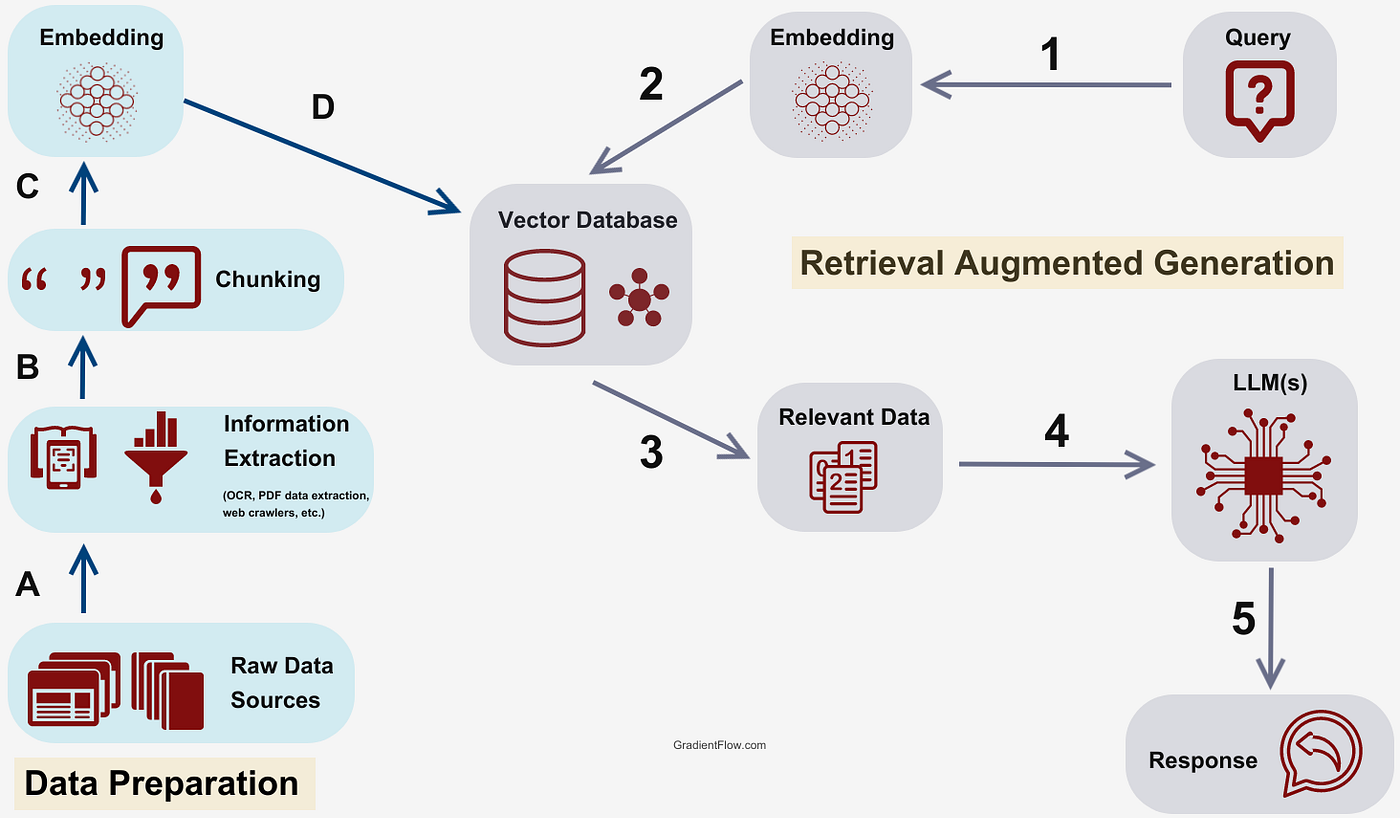

In [ ]:
# !pip install langchain chromadb faiss-cpu langchain-huggingface langchain-community wikipedia langchain_chroma pypdf

In [ ]:
!pip install -q --upgrade pip
!pip install -q \
    transformers \
    accelerate \
    bitsandbytes \
    safetensors \
    langchain \
    langchain-huggingface \
    langchain-community \
    chromadb \
    langchain_chroma \
    pypdf

# Import Libraries

In [ ]:
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline, HuggingFaceEmbeddings

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig

In [ ]:
from langchain_core.prompts import PromptTemplate

In [ ]:
from langchain_chroma import Chroma

In [ ]:
from langchain_core.documents import Document
from langchain_community.document_loaders  import PyPDFLoader, DirectoryLoader

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
from langchain_core.runnables import RunnableParallel, RunnableLambda
from langchain_core.runnables import RunnableSequence, RunnablePassthrough

In [ ]:
from langchain_core.output_parsers import StrOutputParser

In [ ]:
import shutil
import os

In [ ]:
import torch

# Model Load

- Model Source: https://huggingface.co/Qwen/Qwen2.5-7B-Instruct

In [ ]:
chat_model_name = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(chat_model_name)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

hf_llm = AutoModelForCausalLM.from_pretrained(
    chat_model_name,
    quantization_config=bnb_config,
    device_map="auto"
)


print("Model loaded successfully!")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded successfully!


In [ ]:
pipe = pipeline(
    "text-generation",
    model=hf_llm,
    tokenizer=tokenizer,
    max_new_tokens=200,
    do_sample=True,
    temperature=0.3,
    top_p=0.95,
    repetition_penalty=1.15,
    return_full_text=False,
    eos_token_id=tokenizer.eos_token_id,
    device_map="auto"
)

llm_model = HuggingFacePipeline(
    pipeline=pipe,
    pipeline_kwargs={
        "stop_sequences": ["<|im_start|>", "<|im_end|>"]
    }
)

chat_model = ChatHuggingFace(
    llm=llm_model,
    tokenizer=tokenizer,
    chat_template=False
)

Device set to use cuda:0


## Embedding Model

In [ ]:
embeddings_model_name = "Qwen/Qwen3-Embedding-0.6B"

embedding_model = HuggingFaceEmbeddings(
    model_name = embeddings_model_name,
    model_kwargs={"device": "cuda"},
    encode_kwargs={
        "normalize_embeddings": True,
        "batch_size": 8
    }
)

# Step: 1 - Indexing

## 1.1 Documents Ingestion

In [ ]:
dir_loader = DirectoryLoader(path='data/', glob='*.pdf', loader_cls=PyPDFLoader)

In [ ]:
documents = dir_loader.load()

In [ ]:
len(documents)

510

In [ ]:
documents[152]

Document(metadata={'producer': 'Acrobat Distiller 6.0.1 (Windows)', 'creator': 'Adobe InDesign CS3 (5.0.3)', 'creationdate': '2009-02-11T16:49:47-05:00', 'author': 'The National Gardening Association', 'moddate': '2009-08-17T14:26:20+03:00', 'title': 'Organic Gardening for Dummies', 'source': 'data/Organic_Gardening_For_Dummies.pdf', 'total_pages': 388, 'page': 152, 'page_label': '129'}, page_content='129 Chapter 8: Managing Insect Pests\nsap circulation, causing wilting and twig or cane death. Prevent borers \nby choosing plant species that are less susceptible, wrapping the trunks \nof young trees to prevent sunburn or other wounds where borers can \nattack, and covering susceptible vegetable crops with floating row-\ncover fabric. Watch for signs of damage, including dead bark, sawdust \npiles, dead or wilted canes and limbs, and poor performance. Control \nby slitting open affected stems and killing the larvae or pruning off and \ndestroying stems. If you find borers or bark beetle

### Add file-level metadata

In [ ]:
for doc in documents:
    doc.metadata["type"] = "pdf"

## 1.2 Text Chunking

| Use Case                   | chunk_size | overlap |
| -------------------------- | ---------- | ------- |
| QA / RAG (general)         | 800–1200   | 100–200 |
| Long legal / research docs | 1200–2000  | 200–300 |
| Small PDFs / invoices      | 400–600    | 50–100  |


In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    separators = ["\n\n", "\n", " ", ""],
    chunk_size = 1000,
    chunk_overlap = 150
)

split_docs = text_splitter.split_documents(documents)

In [ ]:
len(split_docs)

1351

## 1.3 Embedding Generation

In [ ]:
chroma_store = Chroma(
    collection_name="my_garden",
    embedding_function=embedding_model,
    persist_directory="my_chromadb"
)

chroma_store.add_documents(split_docs)

['07cf33e7-8d0f-4dfe-866e-b3c142c628dc',
 '86fffe15-1538-40cf-9601-4c701f553d1b',
 '4c14f637-60c9-43f8-836f-a9c5791a1982',
 'f8a25c75-e004-43bc-92a0-03e7fa3727ec',
 '3a9bf21f-7e7d-4a9b-81ce-c7e0a56af4c0',
 '3f9c0a7b-3ebd-4401-9080-cf1b55686106',
 '6ae86910-0b8b-41b8-bd14-802eb7eab681',
 '1d2e8ae5-3d9a-40a5-905d-c161d5f0dc69',
 '56c15a92-fc89-4e81-a55e-dd7b5634a32c',
 '9e17fac8-7b50-41d9-82d9-ad4450666eb2',
 'fb9bb30c-ae81-4eaf-9efe-7cf3f90fa2c9',
 '60cecc18-a3ee-4e0f-a5b9-67c0f3bb927e',
 '493d1129-776c-45f2-9f66-fa2fe35cb30c',
 '7bd1f421-ff61-4caa-aaff-295d7f7f0bd6',
 '5155701a-9a7f-465c-9249-ca0ec352e155',
 '27c5b6f4-34c5-40b8-a991-de806cd20fe4',
 'a6056dd6-2589-4538-b914-26e52490320f',
 'af28472d-0c55-414d-94a6-25fb4d7621d7',
 '32309d27-84c1-4970-b3e2-59d45344e829',
 'e89b77ad-4ea5-4de2-8588-0fe9b5ea8a6d',
 '04c8a0cb-7180-4e9a-b946-e181e98eb780',
 'e090923e-e1f3-47d7-b52d-7fb3d804b023',
 '38fc1629-8ddf-470f-89a5-6d0434d11715',
 '3c5bafbe-8718-47b6-90de-f2a7ddf044f4',
 'dc7eb17c-59cd-

In [ ]:
print(chroma_store._collection.count())

2702


In [ ]:
collection = chroma_store._collection

results = collection.get(
    include=["embeddings", "documents", "metadatas"]
)

# View first vector
print(results["embeddings"][0])
print("Vector length:", len(results["embeddings"][0]))

[ 0.01744627  0.04295163 -0.00476331 ... -0.02010981 -0.05918285
 -0.00995247]
Vector length: 1024


## 1.4 Make ZIP file

In [ ]:
# Create a zip of the entire Chroma folder
shutil.make_archive(
    base_name="/content/my_chromadb",  # output zip path
    format="zip",
    root_dir="/content",
    base_dir="my_chromadb"
)

'/content/my_chromadb.zip'

In [ ]:
chroma_store.get_by_ids(['940c3f9c-b3fe-456f-b324-d6d950ed7599'])

[]

[]

# Step: 2 - Retrievers

In [ ]:
retriever = chroma_store.as_retriever(
    search_type = 'similarity',
    search_kwargs={"k": 3}
)

In [ ]:
query = "How can environmental factors affect plant health, and why might their damage be mistaken for disease?"
result = retriever.invoke(query)
result

[Document(id='2ef94e59-3ae8-4ab4-bdee-f89e97d605fe', metadata={'producer': 'Acrobat Distiller 6.0.1 (Windows)', 'author': 'The National Gardening Association', 'source': 'data/Organic_Gardening_For_Dummies.pdf', 'total_pages': 388, 'page': 164, 'moddate': '2009-08-17T14:26:20+03:00', 'title': 'Organic Gardening for Dummies', 'creationdate': '2009-02-11T16:49:47-05:00', 'creator': 'Adobe InDesign CS3 (5.0.3)', 'type': 'pdf', 'page_label': '141'}, page_content='Chapter 9\nBattling Plant Diseases\nIn This Chapter\n▶ Figuring out the problem\n▶ Preventing plant diseases\n▶ Identifying the disease\n▶ Using safe pesticides to treat disease\n▶ Scouting out environmental problems\nW\nhen it comes to diseases, prevention is the name of the game. You \ncan do your part to prevent disease through thoughtful garden and \nlandscape planning and maintenance. But what do you do when disease does \nstrike? How can you tell whether the problem is a disease or some other \nmalady?\nIn this chapter, I ex

# Step 3: - Augmentation

In [ ]:
prompt_template = PromptTemplate(
    template = """
You are a helpful RAG-based AI assistant.

You act as an expert gardener who provides information related to:
- plants
- plant diseases
- fertilizers
- plant care

IMPORTANT RULES:
- Answer strictly and only using the provided context.
- Do NOT use prior knowledge or external information.
- Do NOT make assumptions.
- If the answer is not present in the context, reply exactly with: "I don't know."

Context is retrieved from a Chroma vector database.

**Context:**
{context}

**Question:**
{question}
""",
    input_variables=["context", "question"]
)

In [ ]:
query = "How can environmental factors affect plant health, and why might their damage be mistaken for disease?"
# prompt = prompt_template.invoke({context})
retriever_context = retriever.invoke(query)

context = "\n\n".join(doc.page_content for doc in retriever_context)

In [ ]:
prompt = prompt_template.invoke({
    'context': context,
    'question': query
})

In [ ]:
retriever_context[2].page_content

'142 Part III: Managing Pests \nThe first step in diagnosing a disease problem is gathering all the facts. Start \nby looking at overall conditions:\n ✓ Environment: Check soil moisture and pH (see Chapter 5); recall any \nfertilizers or other amendments you’ve used recently (see Chapter \n6); rule out unusually hot or cold temperatures; consider wet or dry \nweather; and look for mechanical damage, such as severed roots, leaves \ntorn by high winds or hail, or string-trimmer injury. If you applied a her-\nbicide recently, consider whether it could have drifted onto the affected \nplant.\n ✓ Insect activity: Examine leaves and stems for obvious pests and sticky \nresidue or droppings. Dig gently around the roots for grub and nema-\ntode damage. Refer to Chapter 8 for descriptions of insect pests and the \ndamage they cause.\n ✓ Comparison with healthy plants: Note specific differences between \nhealthy specimens and troubled ones. Check leaf color and size, as well'

In [ ]:
prompt

StringPromptValue(text='\nYou are a helpful RAG-based AI assistant.\n\nYou act as an expert gardener who provides information related to:\n- plants\n- plant diseases\n- fertilizers\n- plant care\n\nIMPORTANT RULES:\n- Answer strictly and only using the provided context.\n- Do NOT use prior knowledge or external information.\n- Do NOT make assumptions.\n- If the answer is not present in the context, reply exactly with: "I don\'t know."\n\nContext is retrieved from a Chroma vector database.\n\n**Context:**\nChapter 9\nBattling Plant Diseases\nIn This Chapter\n▶ Figuring out the problem\n▶ Preventing plant diseases\n▶ Identifying the disease\n▶ Using safe pesticides to treat disease\n▶ Scouting out environmental problems\nW\nhen it comes to diseases, prevention is the name of the game. You \ncan do your part to prevent disease through thoughtful garden and \nlandscape planning and maintenance. But what do you do when disease does \nstrike? How can you tell whether the problem is a disease

# Step 4: - Text Generation

In [ ]:
%%time
llm_result = chat_model.invoke(prompt)
llm_result

CPU times: user 18.5 s, sys: 1.29 s, total: 19.8 s
Wall time: 37.1 s


AIMessage(content="Environmental factors such as soil moisture levels, soil pH, recent fertilizer applications, temperature extremes, weather patterns like drought or excessive rain, and physical damage from gardening activities can significantly impact plant health. These factors can lead to symptoms that mimic those caused by diseases. For example, underwatered or overwatered plants might show signs of wilt, which could be confused with a fungal infection if not properly diagnosed. Similarly, extreme heat or cold can stress plants, causing them to appear diseased even though no pathogen is involved. Therefore, it's important to consider these environmental aspects when trying to determine the true cause of plant issues.", additional_kwargs={}, response_metadata={}, id='lc_run--019b655b-18e5-7ab2-b78b-2d7cd26d45cf-0')

# Build Chain

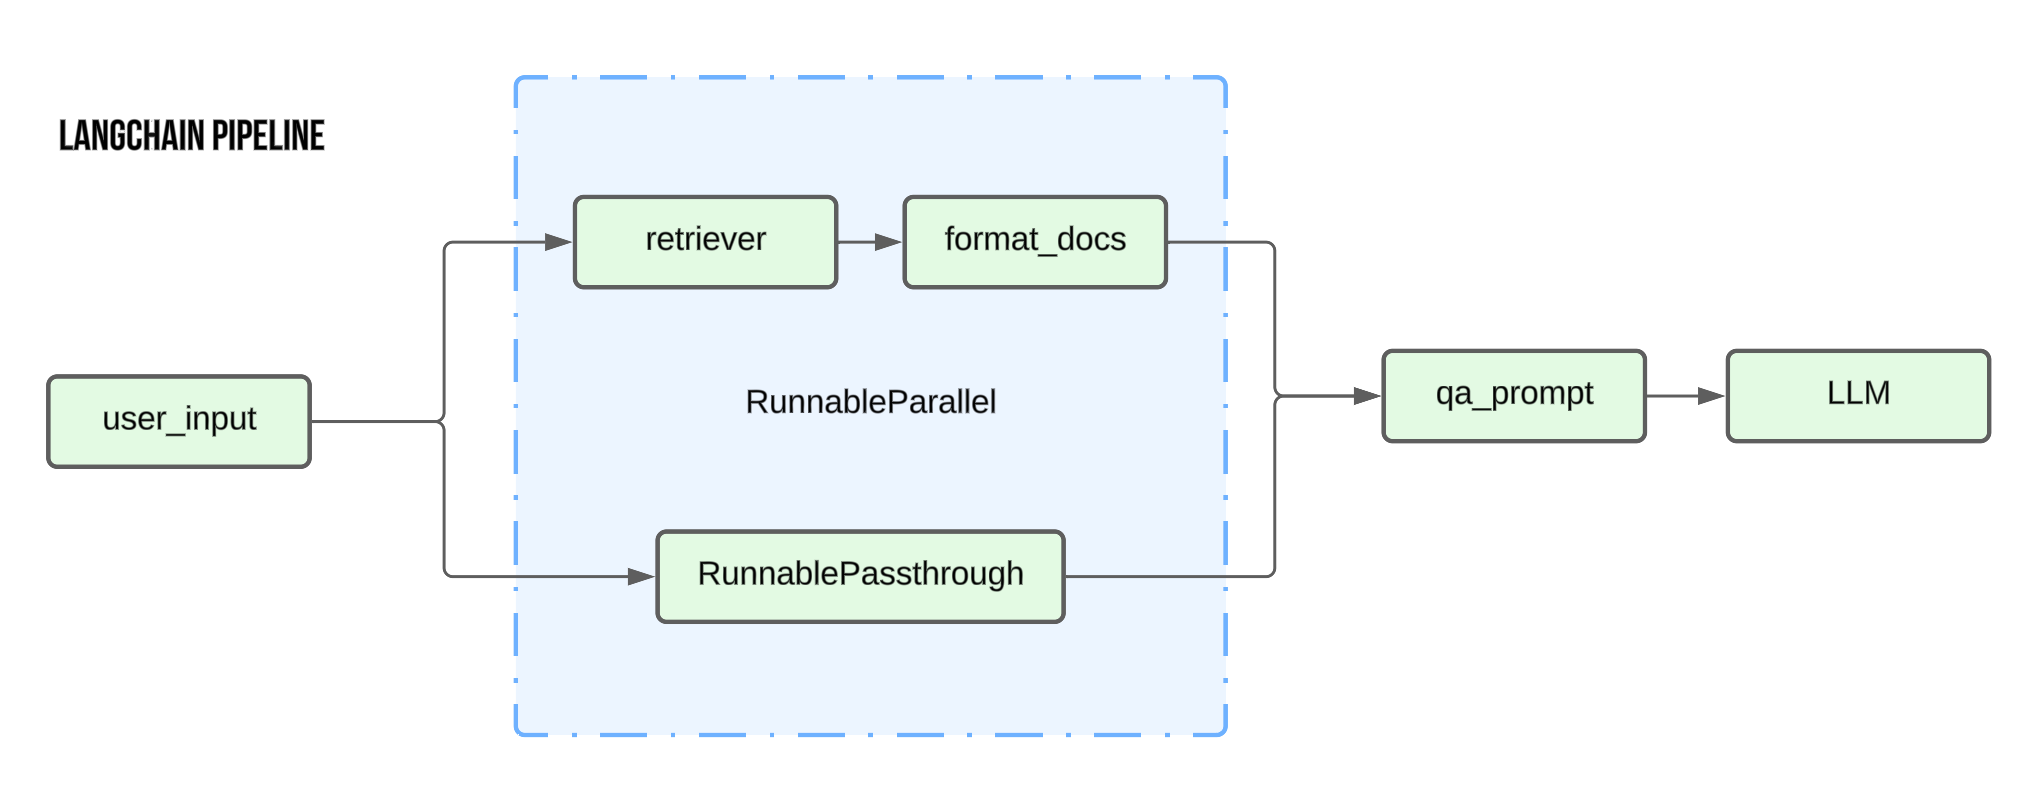

In [ ]:
def format_doc(docs):
    if not docs:
        return ""
    return "\n\n".join(doc.page_content for doc in docs)


## Parallel Chain

In [ ]:
parallel_chain = RunnableParallel({
    'context': retriever | RunnableLambda(format_doc),
    'question' : RunnablePassthrough()
})

In [ ]:
parallel_chain.invoke('How to grow First Vegetable Garden')

{'context': 'Part IV\nGrowing Organically \nin Your Yard and \nGarden\n\nPart IV\nGrowing Organically \nin Your Yard and \nGarden\n\n196 Part IV: Growing Organically in Your Yard and Garden',
 'question': 'How to grow First Vegetable Garden'}

## Build Sequential Chain

In [ ]:
parser = StrOutputParser()

In [ ]:
# Final Chain Build
main_chain = parallel_chain | prompt_template | chat_model | parser

### Query   1

In [ ]:
%%time

query = "How to grow First Vegetable Garden"

main_result = main_chain.invoke(query)
main_result

CPU times: user 23.1 s, sys: 286 ms, total: 23.4 s
Wall time: 32.1 s


'To start your first vegetable garden organically, follow these steps:\n\n1. **Choose a Location**: Select a spot that receives at least 6 hours of sunlight per day. Ensure good drainage and protection from strong winds.\n\n2. **Prepare the Soil**: Test the soil for pH levels and nutrient content. Amend it with organic matter such as compost to improve fertility and structure. Avoid chemical fertilizers and pesticides; opt for natural alternatives like compost tea or worm castings.\n\n3. **Select Vegetables**: Choose vegetables suitable for your climate zone. Start with easy-to-grow varieties like tomatoes, lettuce, radishes, and beans.\n\n4. **Planting**: Plant seeds according to their specific needs regarding depth and spacing. Water gently after planting but avoid overwatering.\n\n5. **Mulching**: Apply a layer of mulch around plants to retain moisture, suppress weeds, and regulate temperature.\n\n6. **Watering**: Provide consistent watering—vegetable gardens often need about 1 inch

### Query 2:

In [ ]:
%%time

query2 = "what is AI"

# retriever.invoke(query)
main_result2 = main_chain.invoke(query2)
main_result2

CPU times: user 1.46 s, sys: 347 ms, total: 1.8 s
Wall time: 1.84 s


"I don't know."